# Grid Demand Forecasting
**Predictive Paradox – ML Pipeline**

Using PGCB power data + weather + macroeconomic indicators to predict grid demand with Random Forest.

Datasets needed:
- `PGCB_date_power_demand (1).xlsx - Sheet1.csv`
- `economic_full_1.csv`
- `weather_data.xlsx`

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load the Data

In [19]:

power_df    = pd.read_excel('PGCB_date_power_demand.xlsx')
weather_df = pd.read_excel('weather_data.xlsx')
economic_df = pd.read_csv('economic_full_1.csv')


print('power   :', power_df.shape)
print('weather :', weather_df.shape)
print('economic:', economic_df.shape)

power   : (92650, 15)
weather : (107307, 10)
economic: (1516, 69)


In [20]:

power_df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [35]:
weather_df.head()

,latitude,longitude,elevation,utc_offset_seconds,datetime,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2014-01-01 00:00:00,13.9,89,13.3,1970-01-01,12.1,16.4,313,0,0
1,2014-10-01 17:00:00,31.2,64,36.6,1970-01-01,23.6,32.1,306,7,3600
2,2014-10-01 19:00:00,29.8,72,35.7,1970-01-01,24.2,29.6,360,1,0
3,2014-09-30 06:00:00,25.7,93,31.6,1970-01-01,24.4,26,54,6,0
4,2014-10-01 20:00:00,29.2,76,35.4,1970-01-01,24.4,28.8,117,0,0


In [36]:
economic_df.head()


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,...,41.000000,47.000000,47.000000,47.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,27.450981,27.450981
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,28.891353,28.891353,28.891353,28.891353,28.891353,28.891353,28.891353,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,23.495141
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,63.583179,63.583179,63.583179,63.583179,63.583179,63.583179,63.583179,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,65.566600


In [37]:
power_df.isna().sum()
weather_df.isna().sum()
economic_df.isna().sum()

Country Name       0
Indicator Name     0
Indicator Code     0
1960              56
1961              56
                  ..
2021              56
2022              56
2023              56
2024              56
2025              56
Length: 69, dtype: int64

In [39]:
power_df.duplicated().sum()
       

np.int64(0)

In [40]:
weather_df.duplicated().sum()

np.int64(0)

In [21]:
power_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[us]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal                 5351 

## 2. Clean Each Dataset

Text(0.5, 0, 'datetime')

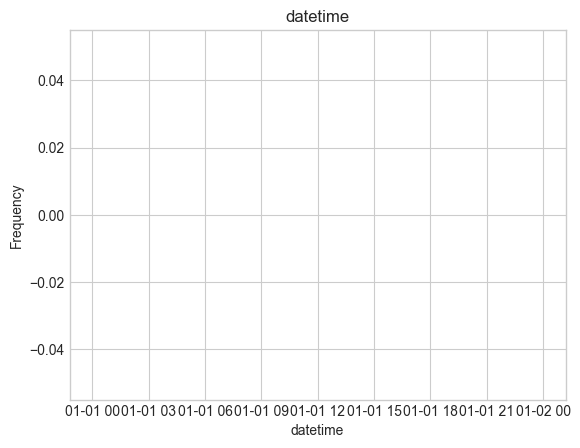

In [41]:
ax = power_df['datetime'].plot(kind='hist',
                          bins=20,
                          title='datetime')
ax.set_xlabel('datetime')

In [46]:
power_df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,india_adani,nepal,Hour,DayOfWeek,Month,Year,Is_Weekend,demand_lag_1h,demand_lag_24h,demand_rolling_mean_24h
24,2015-04-19 22:00:00,6323.0,6323.0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,22,6,4,2015,1,6667.0,4821.0,5135.791667
25,2015-04-20 00:00:00,5678.0,5678.0,0,4140,895,162,40,0.0,0.0,...,0.0,0.0,0,0,4,2015,0,6323.0,3612.0,5221.875000
26,2015-04-20 07:00:00,5183.0,5183.0,0,3989,571,152,30,0.0,0.0,...,0.0,0.0,7,0,4,2015,0,5678.0,3727.0,5282.541667
27,2015-04-20 08:00:00,5569.0,5569.0,0,4209,738,151,30,0.0,0.0,...,0.0,0.0,8,0,4,2015,0,5183.0,3632.0,5363.250000
28,2015-04-20 09:00:00,5603.0,5603.0,0,4014,956,149,42,0.0,0.0,...,0.0,0.0,9,0,4,2015,0,5569.0,3641.0,5445.000000


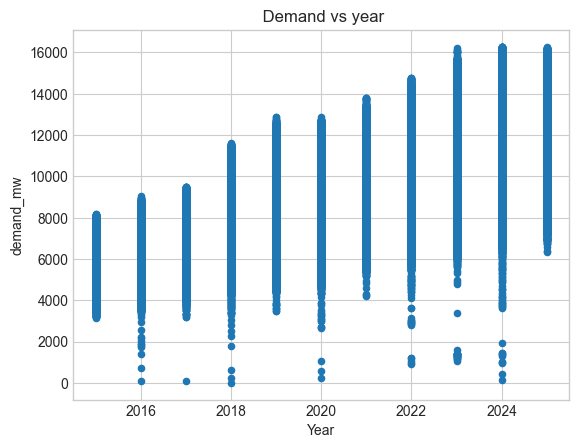

In [50]:
power_df.plot(kind='scatter',
        x='Year',
        y='demand_mw',
        title=' Demand vs year')
plt.show()

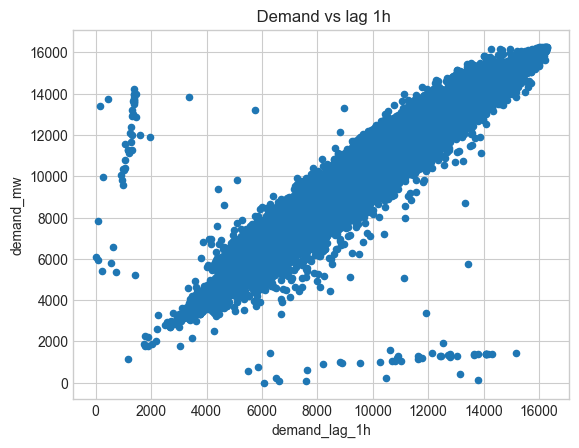

In [51]:
power_df.plot(kind='scatter',
        x='demand_lag_1h',
        y='demand_mw',
        title=' Demand vs lag 1h')
plt.show()

In [22]:
#Power 
power_df['datetime'] = pd.to_datetime(power_df['datetime'], errors='coerce')
power_df = power_df.sort_values('datetime').reset_index(drop=True)

# zeros 
power_df['demand_mw'] = power_df['demand_mw'].replace(0, np.nan)

# kill extreme outliers (top 0.1%)
cap = power_df['demand_mw'].quantile(0.999)
power_df.loc[power_df['demand_mw'] > cap, 'demand_mw'] = np.nan

power_df['demand_mw'] = power_df['demand_mw'].interpolate(method='linear')

# these sources weren't built for most of the dataset period
not_yet_built = ['solar', 'wind', 'india_adani', 'nepal']
power_df[not_yet_built] = power_df[not_yet_built].fillna(0)

power_df = power_df.drop(columns=['remarks'], errors='ignore')

print('null counts after cleaning:')
print(power_df.isnull().sum()[power_df.isnull().sum() > 0])

null counts after cleaning:
Series([], dtype: int64)


In [23]:
# Auto-detect the datetime column
date_col = None
for col in weather_df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
        break

if date_col:
    weather_df[date_col] = pd.to_datetime(weather_df[date_col], errors='coerce')
    weather_df = weather_df.sort_values(date_col).reset_index(drop=True)
    weather_df = weather_df.rename(columns={date_col: 'datetime'})  # standardize name
    print(f"Found date column: '{date_col}' → renamed to 'datetime'")
else:
    print("No date column found. Columns are:", weather_df.columns.tolist())

num_cols = weather_df.select_dtypes(include=[np.number]).columns
weather_df[num_cols] = weather_df[num_cols].interpolate(method='linear')
weather_df[num_cols] = weather_df[num_cols].bfill().ffill()

weather_df.head(3)

Found date column: 'timezone' → renamed to 'datetime'


,latitude,longitude,elevation,utc_offset_seconds,datetime,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2014-01-01 00:00:00,13.9,89,13.3,1970-01-01,12.1,16.4,313,0,0
1,2022-01-27 19:00:00,16.2,73,15.4,1970-01-01,11.3,20,297,0,0
2,2022-01-27 18:00:00,17.2,68,16.5,1970-01-01,11.2,21.5,292,0,226.3


In [24]:
#  Weather
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')
weather_df = weather_df.sort_values('datetime').reset_index(drop=True)

num_cols = weather_df.select_dtypes(include=[np.number]).columns
weather_df[num_cols] = weather_df[num_cols].interpolate(method='linear')
weather_df[num_cols] = weather_df[num_cols].bfill().ffill()

weather_df.head(3)

,latitude,longitude,elevation,utc_offset_seconds,datetime,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2014-01-01 00:00:00,13.9,89,13.3,1970-01-01,12.1,16.4,313,0,0
1,2014-10-01 17:00:00,31.2,64,36.6,1970-01-01,23.6,32.1,306,7,3600
2,2014-10-01 19:00:00,29.8,72,35.7,1970-01-01,24.2,29.6,360,1,0


In [25]:
# Economic 
# wide format – columns are years
year_cols = [c for c in economic_df.columns if c.isnumeric()]

# if a year is missing just carry the previous year's value forward
economic_df[year_cols] = economic_df[year_cols].ffill(axis=1).bfill(axis=1)

economic_df.head(3)

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,26.0,26.0,26.0,26.0,26.0,26.0,26.0,...,41.000000,47.000000,47.000000,47.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,50.0,50.0,50.0,50.0,50.0,50.0,50.0,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,27.450981,27.450981


## 3. Feature Engineering

In [ ]:
# time-based features
power_df['Hour']       = power_df['datetime'].dt.hour
power_df['DayOfWeek']  = power_df['datetime'].dt.dayofweek
power_df['Month']      = power_df['datetime'].dt.month
power_df['Year']       = power_df['datetime'].dt.year
power_df['Is_Weekend'] = (power_df['DayOfWeek'] >= 5).astype(int)

# lag features 
power_df['demand_lag_1h']           = power_df['demand_mw'].shift(1)
power_df['demand_lag_24h']          = power_df['demand_mw'].shift(24)
power_df['demand_rolling_mean_24h'] = power_df['demand_mw'].rolling(24).mean()

# first 24 rows won't have valid lag values so drop them
power_df = power_df.dropna(subset=['demand_lag_24h', 'demand_rolling_mean_24h']).copy()

print('After feature engineering:', power_df.shape)

After feature engineering: (92626, 22)


## 4. Merge Everything

In [27]:
# reshape economic data from wide → long → pivot so each indicator becomes a column
econ_long = pd.melt(
    economic_df,
    id_vars=['Indicator Name'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

econ_pivot = econ_long.pivot_table(
    index='Year', columns='Indicator Name', values='Value'
).reset_index()

econ_pivot['Year'] = econ_pivot['Year'].astype(int)

econ_pivot.head(3)

Indicator Name,Year,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,1960,27.0,7.7,0.7,34.1,14.29,3.171019,58.060595,31.743649,26.011697,...,31.0,21.5,4.1,17.9,16.0,9.1,47.2,73.3,25.929321,100.0
1,1961,27.0,7.7,0.7,34.1,14.29,3.171019,58.060595,31.743649,26.011697,...,31.0,21.5,4.1,17.9,16.0,9.1,47.2,73.3,25.929321,100.0
2,1962,27.0,7.7,0.7,34.1,14.29,3.171019,58.060595,31.743649,26.011697,...,31.0,21.5,4.1,17.9,16.0,9.1,47.2,73.3,25.929321,100.0


In [28]:
master = power_df.merge(weather_df, on='datetime', how='left')
master = master.merge(econ_pivot, on='Year', how='left')

master = master.sort_values('datetime')
master = master.ffill().bfill()
master = master.set_index('datetime')

print('Master frame shape:', master.shape)
master.head()

Master frame shape: (92626, 1490)


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323.0,0,0,0,0,0,0.0,0.0,0,...,28.3,19.9,4.3,14.4,14.9,7.2,22.4,58.6,32.018299,500.0
2015-04-20 00:00:00,5678.0,5678.0,0,4140,895,162,40,0.0,0.0,441,...,28.3,19.9,4.3,14.4,14.9,7.2,22.4,58.6,32.018299,500.0
2015-04-20 07:00:00,5183.0,5183.0,0,3989,571,152,30,0.0,0.0,441,...,28.3,19.9,4.3,14.4,14.9,7.2,22.4,58.6,32.018299,500.0
2015-04-20 08:00:00,5569.0,5569.0,0,4209,738,151,30,0.0,0.0,441,...,28.3,19.9,4.3,14.4,14.9,7.2,22.4,58.6,32.018299,500.0
2015-04-20 09:00:00,5603.0,5603.0,0,4014,956,149,42,0.0,0.0,442,...,28.3,19.9,4.3,14.4,14.9,7.2,22.4,58.6,32.018299,500.0


## 5. Train / Test Split & Model

In [29]:
# drop columns that are themselves generated by demand (would leak future info)
leak_cols = [
    'generation_mw', 'load_shedding', 'gas', 'liquid_fuel',
    'coal', 'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal'
]

X = master.drop(columns=['demand_mw'] + leak_cols, errors='ignore')
y = master['demand_mw']

split = int(len(master) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')

Train size: 74100  |  Test size: 18526


In [30]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Training done.')

Training done.


## 6. Evaluate

In [31]:
preds = rf.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)

print(f'MAE  : {mae:.2f} MW')
print(f'MAPE : {mape * 100:.2f}%')

MAE  : 281.79 MW
MAPE : 3.80%


## 7. Visualise Results

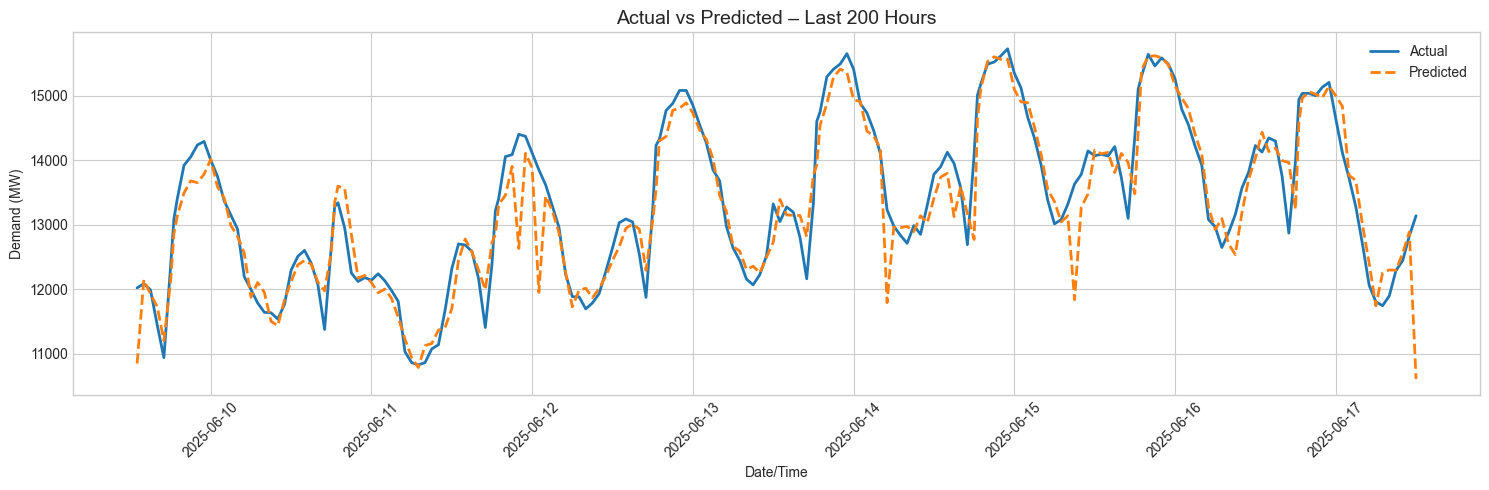

In [32]:
# zoom into last 200 hours so we can actually read the lines
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(y_test.index[-200:], y_test.values[-200:],
        label='Actual', color='#1f77b4', linewidth=2)

ax.plot(y_test.index[-200:], preds[-200:],
        label='Predicted', color='#ff7f0e', linestyle='--', linewidth=2)

ax.set_title('Actual vs Predicted – Last 200 Hours', fontsize=14)
ax.set_xlabel('Date/Time')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

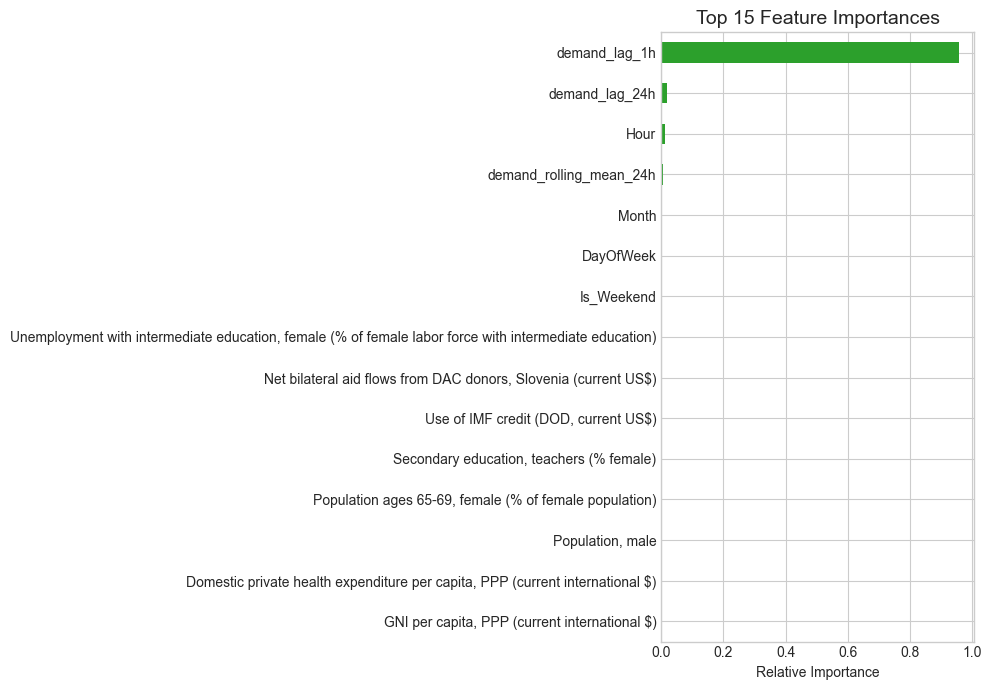

In [33]:
# feature importance – which variables actually drive demand?
imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.sort_values().plot(kind='barh', ax=ax, color='#2ca02c')

ax.set_title('Top 15 Feature Importances', fontsize=14)
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [34]:



from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

# Calculate metrics
mae  = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)
mse  = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, preds)

# Print results
print("--- Model Efficiency Metrics ---")
print(f"Mean Absolute Error        (MAE):  {mae:.2f} MW")
print(f"Mean Abs Percentage Error (MAPE):  {mape:.4f}")
print(f"Root Mean Squared Error   (RMSE):  {rmse:.2f} MW")
print(f"R² Score                    (R²):  {r2:.4f}")

--- Model Efficiency Metrics ---
Mean Absolute Error        (MAE):  281.79 MW
Mean Abs Percentage Error (MAPE):  0.0380
Root Mean Squared Error   (RMSE):  590.00 MW
R² Score                    (R²):  0.9361
